In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Configuración
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("="*80)
print("📊 PREDICCIÓN DE APROBACIÓN - Estatica")
print("🤖 REGRESIÓN LOGÍSTICA")
print("="*80)

# =============================================================================
# 1. CARGAR DATOS
# =============================================================================
print("\n📂 Cargando datos concatenados...")
try:
    df =pd.read_csv(r'datos_clean.csv')

    print(f"✅ Datos cargados: {len(df):,} registros")
except FileNotFoundError:
    print("❌ No se encontró el archivo 'datosConcatenados.csv'")
    exit()

📊 PREDICCIÓN DE APROBACIÓN - Estatica
🤖 REGRESIÓN LOGÍSTICA

📂 Cargando datos concatenados...
✅ Datos cargados: 64,295 registros


In [2]:
# =============================================================================
# 2. FILTRAR Estatica
# =============================================================================
print("\n🔍 Filtrando Estatica...")
mask = df['Asignatura'].str.upper().str.contains('ESTATICA', na=False)
df_estatica = df[mask].copy()
print(f"✅ Registros de Estatica: {len(df_estatica):,}")
print(f"   Estudiantes únicos: {df_estatica['ALUMNO_ID'].nunique():,}")

if len(df_estatica) == 0:
    print("❌ No se encontraron registros de Estatica")
    exit()


🔍 Filtrando Estatica...
✅ Registros de Estatica: 1,798
   Estudiantes únicos: 1,183


In [8]:
# =============================================================================
# 2. FILTRAR Mecanica y Calor Y EXCLUIR Ingeniería Electrónica
# =============================================================================
print("\n🔍 Filtrando Mecanica y Calor para carreras que lleven estatica")

if 'Carrera_Nombre' not in df.columns:
    raise KeyError("La columna 'Carrera_Nombre' no existe en el DataFrame")

mask = (
    df['Asignatura'].str.upper().str.contains('MECANICA Y CALOR', na=False)
    & df['Carrera_Nombre'].ne('Ing. Electrónica') & df['Carrera_Nombre'].ne('Ing. Geográfica')
)
df_MyC = df[mask].copy()
print(f"✅ Registros de Mecanica y Calor que lleven estatica: {len(df_MyC):,}")
print(f"   Estudiantes únicos: {df_MyC['ALUMNO_ID'].nunique():,}")

if len(df_MyC) == 0:
    print("❌ No se encontraron registros de Mecanica y Calor fuera de Electrónica o Geográfica")
    exit()


🔍 Filtrando Mecanica y Calor para carreras que lleven estatica
✅ Registros de Mecanica y Calor que lleven estatica: 1,081
   Estudiantes únicos: 782


In [9]:
# =============================================================================
# 2. FILTRAR Calculo 2 Y EXCLUIR Ingeniería Electrónica/geografica
# =============================================================================
print("\n🔍 Filtrando Calculo 2 para carreras distintas de Electrónica o Geográfica")

if 'Carrera_Nombre' not in df.columns:
    raise KeyError("La columna 'Carrera_Nombre' no existe en el DataFrame")

mask = (
    df['Asignatura'].str.upper().str.contains('CALCULO 2', na=False)
    & df['Carrera_Nombre'].ne('Ing. Electrónica') & df['Carrera_Nombre'].ne('Ing. Geográfica')
)
df_C2 = df[mask].copy()
print(f"✅ Registros de Calculo 2 que lleven estatica: {len(df_C2):,}")
print(f"   Estudiantes únicos: {df_C2['ALUMNO_ID'].nunique():,}")

if len(df_C2) == 0:
    print("❌ No se encontraron registros de Calculo 2 fuera de Electrónica o Geográfica")
    exit()


🔍 Filtrando Calculo 2 para carreras distintas de Electrónica o Geográfica
✅ Registros de Calculo 2 que lleven estatica: 398
   Estudiantes únicos: 398


In [25]:
# =============================================================================
# 3. UNIR ALUMNOS QUE APROBARON CALCULO 2 Y MECANICA Y CALOR CON ESTATICA
# =============================================================================
print("\n🔗 Buscando alumnos que aprobaron Calculo 2 y Mecanica y Calor...")

columnas_necesarias = {'ALUMNO_ID', 'Aprobado'}
for nombre_df, datos in {
    'df_estatica': df_estatica,
    'df_C2': df_C2,
    'df_MyC': df_MyC
}.items():
    columnas_faltantes = columnas_necesarias - set(datos.columns)
    if columnas_faltantes:
        raise KeyError(f"{nombre_df} no contiene: {sorted(columnas_faltantes)}")

ids_aprobados_c2 = set(
    df_C2.loc[df_C2['Aprobado'].eq('S'), 'ALUMNO_ID'].dropna().unique()
)
ids_aprobados_myc = set(
    df_MyC.loc[df_MyC['Aprobado'].eq('S'), 'ALUMNO_ID'].dropna().unique()
)
ids_aprobados_ambas = ids_aprobados_c2 & ids_aprobados_myc

df_estatica_aprobados = df_estatica[
    df_estatica['ALUMNO_ID'].isin(ids_aprobados_ambas)
].copy()

print(f"✅ Alumnos que aprobaron Calculo 2: {len(ids_aprobados_c2):,}")
print(f"✅ Alumnos que aprobaron Mecanica y Calor: {len(ids_aprobados_myc):,}")
print(f"✅ Alumnos que aprobaron ambas materias: {len(ids_aprobados_ambas):,}")
print(f"✅ Registros de Estatica de esos alumnos: {len(df_estatica_aprobados):,}")

if df_estatica_aprobados.empty:
    print("❌ No se encontraron registros de Estatica para alumnos que aprobaron ambas materias")
    exit()

# Mantener la nota mas alta indicada en valores como '1F-1, 2F-3'.
def extraer_mayor_nota_final(valor):
    if pd.isna(valor):
        return np.nan

    import re
    notas = re.findall(r'\d+F-(\d+(?:\.\d+)?)', str(valor).upper())
    if not notas:
        return np.nan
    return max(float(nota) for nota in notas)

# Mantener un solo registro por alumno y materia para evitar duplicados en el merge.
def ultimo_registro_por_alumno(datos):
    columnas = ['ALUMNO_ID', 'Firma', 'Nota.Final']
    columnas_faltantes = set(columnas) - set(datos.columns)
    if columnas_faltantes:
        raise KeyError(f"Faltan columnas para el merge: {sorted(columnas_faltantes)}")

    datos_ordenados = datos.copy()
    if 'Anho' in datos_ordenados.columns:
        datos_ordenados = datos_ordenados.sort_values('Anho', na_position='first')

    resultado = datos_ordenados[columnas].drop_duplicates('ALUMNO_ID', keep='last').copy()
    resultado['Nota.Final'] = resultado['Nota.Final'].apply(extraer_mayor_nota_final)
    return resultado

df_c2_merge = ultimo_registro_por_alumno(
    df_C2[df_C2['ALUMNO_ID'].isin(ids_aprobados_ambas)]
).rename(columns={
    'Firma': 'Firma_Calculo2',
    'Nota.Final': 'Nota_Final_Calculo2'
})
df_myc_merge = ultimo_registro_por_alumno(
    df_MyC[df_MyC['ALUMNO_ID'].isin(ids_aprobados_ambas)]
).rename(columns={
    'Firma': 'Firma_Mecanica_Calor',
    'Nota.Final': 'Nota_Final_Mecanica_Calor'
})

columnas_merge = [
    'Firma_Calculo2', 'Nota_Final_Calculo2',
    'Firma_Mecanica_Calor', 'Nota_Final_Mecanica_Calor'
]
df_estatica_aprobados = (
    df_estatica_aprobados.drop(columns=columnas_merge, errors='ignore')
    .merge(df_c2_merge, on='ALUMNO_ID', how='left', validate='many_to_one')
    .merge(df_myc_merge, on='ALUMNO_ID', how='left', validate='many_to_one')
)

print("✅ Firmas y notas finales agregadas al DataFrame")
print(f"   Columnas nuevas: {columnas_merge}")
print(f"   Filas resultantes: {len(df_estatica_aprobados):,}")


🔗 Buscando alumnos que aprobaron Calculo 2 y Mecanica y Calor...
✅ Alumnos que aprobaron Calculo 2: 236
✅ Alumnos que aprobaron Mecanica y Calor: 429
✅ Alumnos que aprobaron ambas materias: 106
✅ Registros de Estatica de esos alumnos: 96
✅ Firmas y notas finales agregadas al DataFrame
   Columnas nuevas: ['Firma_Calculo2', 'Nota_Final_Calculo2', 'Firma_Mecanica_Calor', 'Nota_Final_Mecanica_Calor']
   Filas resultantes: 96


In [26]:
df_estatica_aprobados.head(5)

,ALUMNO_ID,Cod.Asign,Asignatura,Cod.Car.Sec,Cod.Curso,Convocatoria,Anho,Semestre,Doc.Firma,Aprobado,Anho.Firma,Primer.Par,Segundo.Par,Tercer.Par,TPLab.,Lab.,Proy.,Pond.PP,Pond.SP,Pond.TPLab,Pond.Lab,Pond.Proy,Asis,Requisito,Firma,Primer.Rec,Segundo.Rec,Nota.Final,Archivo_Origen,FirmaCalculada,Carrera_Nombre,Target,Primer_Par_Clean,Segundo_Par_Clean,Score_Parciales,Diff_Parciales,TPLab_Clean,Asis_Clean,Firma_Clean,FirmaCalc_Clean,Ciclo,Firma_Calculo2,Nota_Final_Calculo2,Firma_Mecanica_Calor,Nota_Final_Mecanica_Calor
0,FIUNA_ALUMNO_012149,23035,ESTATICA,MEC-PLS23,3,2,2025,2,0,N,0,24,28,0,20,0,0,40,40,20,0,0,1,0,25.00,0,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,Ing. Mecánica,0,24,28,26.00,4,20,1,25.00,NaN,2025-2,56.00,2.00,53.00,2.00
1,FIUNA_ALUMNO_012471,23035,ESTATICA,MEC-PLS23,3,2,2025,2,0,N,0,24,28,0,20,0,0,40,40,20,0,0,1,0,25.00,0,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,Ing. Mecánica,0,24,28,26.00,4,20,1,25.00,NaN,2025-2,56.00,2.00,53.00,2.00
2,FIUNA_ALUMNO_012150,23035,ESTATICA,CIV-PLS23,3,2,2025,2,38774,S,2025,52,52,0,40,0,0,40,40,20,0,0,1,1,50.00,0,0,"1F-1,2F-4",rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,Ing. Civil,1,52,52,52.00,0,40,1,50.00,NaN,2025-2,71.00,3.00,72.00,3.00
3,FIUNA_ALUMNO_012472,23035,ESTATICA,CIV-PLS23,3,2,2025,2,38774,S,2025,52,52,0,40,0,0,40,40,20,0,0,1,1,50.00,0,0,"1F-1,2F-4",rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,Ing. Civil,1,52,52,52.00,0,40,1,50.00,NaN,2025-2,71.00,3.00,72.00,3.00
4,FIUNA_ALUMNO_011327,23035,ESTATICA,CIV-PLS23,3,2,2025,2,0,N,0,44,4,0,10,0,0,40,40,20,0,0,1,1,31.00,28,0,NaN,rendimiento_año_2025_ciclo_2_anon.xlsx,NaN,Ing. Civil,0,44,4,24.00,-40,10,1,31.00,NaN,2025-2,35.00,2.00,52.00,2.00


In [35]:
# =============================================================================
# 3. PREPARAR DATOS
# =============================================================================
print("\n🔄 Preparando datos para el modelo...")

# Variables de Estatica y de las materias aprobadas previamente
variables = [
    'Primer.Par', 'Segundo.Par', 'Tercer.Par', 'TPLab.', 'Proy.', 'Firma', 'Anho',
    'Firma_Calculo2', 'Nota_Final_Calculo2',
    'Firma_Mecanica_Calor', 'Nota_Final_Mecanica_Calor'
]
variables_existentes = [v for v in variables if v in df_estatica_aprobados.columns]

print(f"   Variables disponibles: {variables_existentes}")

# Las firmas y notas de las materias extra son valores numéricos.
variables_modelo = variables_existentes.copy()

df_modelo = df_estatica_aprobados[variables_modelo].copy()
df_modelo['Aprobado'] = df_estatica_aprobados['Aprobado'].map({'S': 1, 'N': 0})

for col in variables_modelo:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors='coerce')

df_limpio = df_modelo.dropna()

print(f"   Variables usadas por el modelo: {variables_modelo}")
print(f"   Registros originales: {len(df_modelo):,}")
print(f"   Registros después de limpiar: {len(df_limpio):,}")
print(f"   Proporción de aprobados: {df_limpio['Aprobado'].mean():.2%}")


🔄 Preparando datos para el modelo...
   Variables disponibles: ['Primer.Par', 'Segundo.Par', 'Tercer.Par', 'TPLab.', 'Proy.', 'Firma', 'Anho', 'Firma_Calculo2', 'Nota_Final_Calculo2', 'Firma_Mecanica_Calor', 'Nota_Final_Mecanica_Calor']
   Variables usadas por el modelo: ['Primer.Par', 'Segundo.Par', 'Tercer.Par', 'TPLab.', 'Proy.', 'Firma', 'Anho', 'Firma_Calculo2', 'Nota_Final_Calculo2', 'Firma_Mecanica_Calor', 'Nota_Final_Mecanica_Calor']
   Registros originales: 96
   Registros después de limpiar: 96
   Proporción de aprobados: 58.33%


In [38]:
# =============================================================================
# 3. PREPARAR DATOS
# =============================================================================
print("\n🔄 Preparando datos para el modelo...")

# Solo desempeño en materias previas (sin ninguna nota de Estática -> sin leakage)
variables = [
    'Firma_Calculo2', 'Nota_Final_Calculo2',
    'Firma_Mecanica_Calor', 'Nota_Final_Mecanica_Calor'
]
variables_existentes = [v for v in variables if v in df_estatica_aprobados.columns]

print(f"   Variables disponibles: {variables_existentes}")

variables_modelo = variables_existentes.copy()

df_modelo = df_estatica_aprobados[variables_modelo].copy()
df_modelo['Aprobado'] = df_estatica_aprobados['Aprobado'].map({'S': 1, 'N': 0})

for col in variables_modelo:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors='coerce')

df_limpio = df_modelo.dropna()

print(f"   Variables usadas por el modelo: {variables_modelo}")
print(f"   Registros originales: {len(df_modelo):,}")
print(f"   Registros después de limpiar: {len(df_limpio):,}")
print(f"   Proporción de aprobados: {df_limpio['Aprobado'].mean():.2%}")


🔄 Preparando datos para el modelo...
   Variables disponibles: ['Firma_Calculo2', 'Nota_Final_Calculo2', 'Firma_Mecanica_Calor', 'Nota_Final_Mecanica_Calor']
   Variables usadas por el modelo: ['Firma_Calculo2', 'Nota_Final_Calculo2', 'Firma_Mecanica_Calor', 'Nota_Final_Mecanica_Calor']
   Registros originales: 96
   Registros después de limpiar: 96
   Proporción de aprobados: 58.33%


In [39]:
df_limpio.head(5)

,Firma_Calculo2,Nota_Final_Calculo2,Firma_Mecanica_Calor,Nota_Final_Mecanica_Calor,Aprobado
0,56.00,2.00,53.00,2.00,0
1,56.00,2.00,53.00,2.00,0
2,71.00,3.00,72.00,3.00,1
3,71.00,3.00,72.00,3.00,1
4,35.00,2.00,52.00,2.00,0



📊 ANÁLISIS EXPLORATORIO

📋 Estadísticas por estado (Aprobado vs Reprobado):

Firma_Calculo2:
          count  mean   std   min   max
Aprobado                               
0            40 61.95 11.58 35.00 82.00
1            56 71.82  9.91 52.00 90.00

Nota_Final_Calculo2:
          count  mean  std  min  max
Aprobado                            
0            40  2.60 0.67 2.00 4.00
1            56  3.32 0.81 2.00 5.00

Firma_Mecanica_Calor:
          count  mean   std   min   max
Aprobado                               
0            40 60.70 12.09 29.00 78.00
1            56 73.46 11.16 53.00 93.00

Nota_Final_Mecanica_Calor:
          count  mean  std  min  max
Aprobado                            
0            40  2.50 0.68 2.00 4.00
1            56  3.11 0.95 2.00 5.00

📈 Correlación con Aprobado:
Aprobado                    1.00
Firma_Mecanica_Calor        0.48
Nota_Final_Calculo2         0.43
Firma_Calculo2              0.42
Nota_Final_Mecanica_Calor   0.34
Name: Aprobado, dtype: 

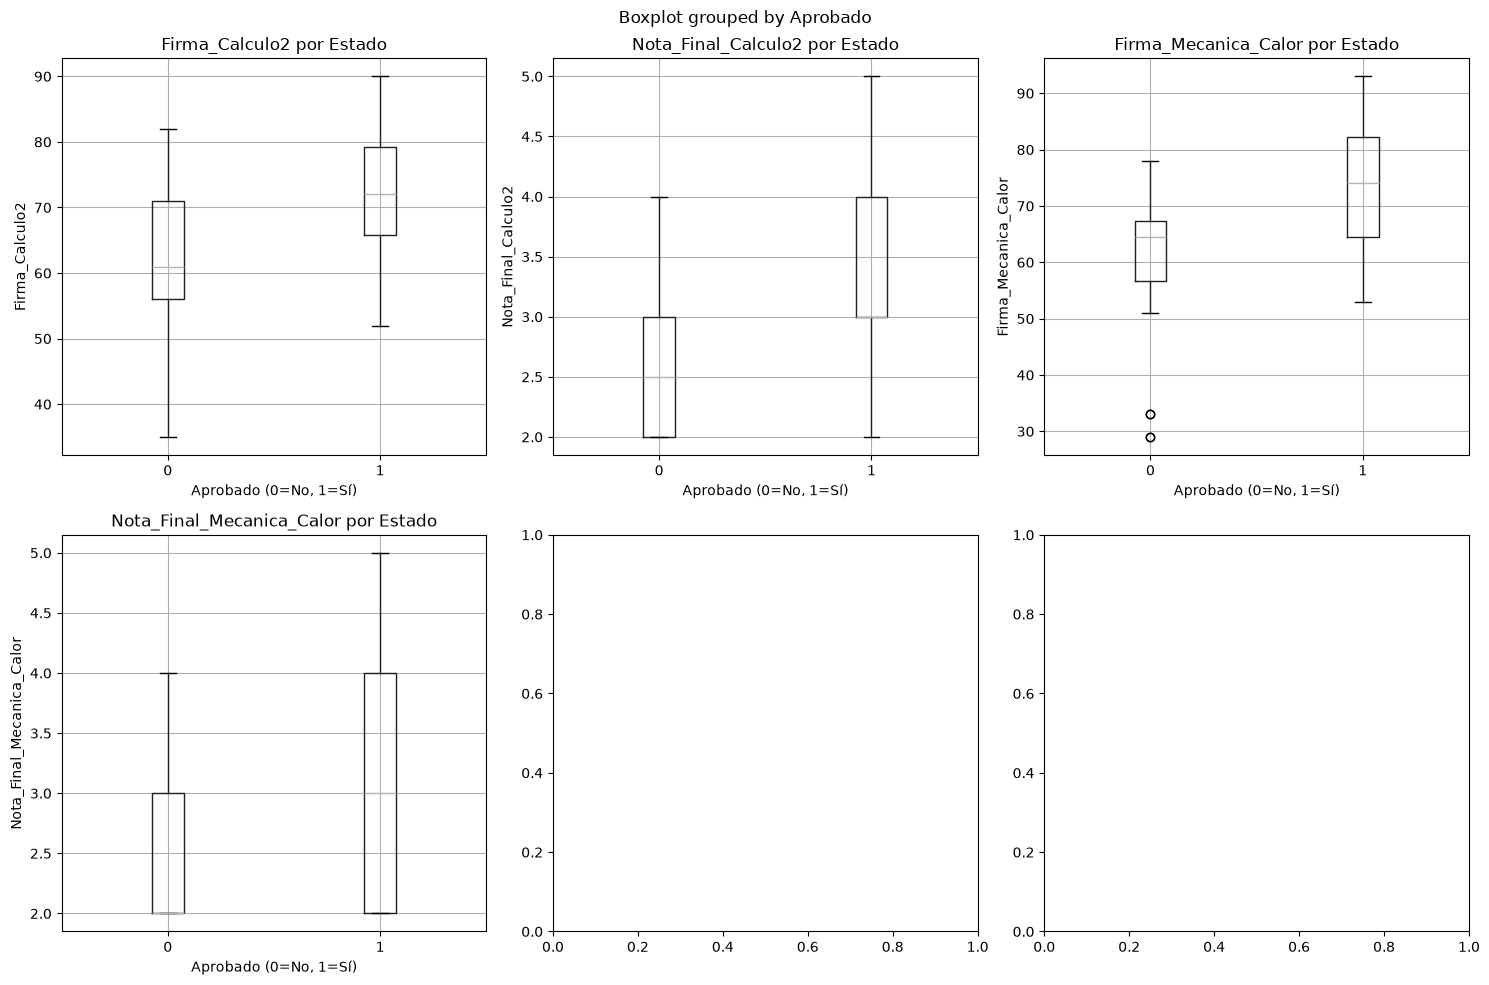

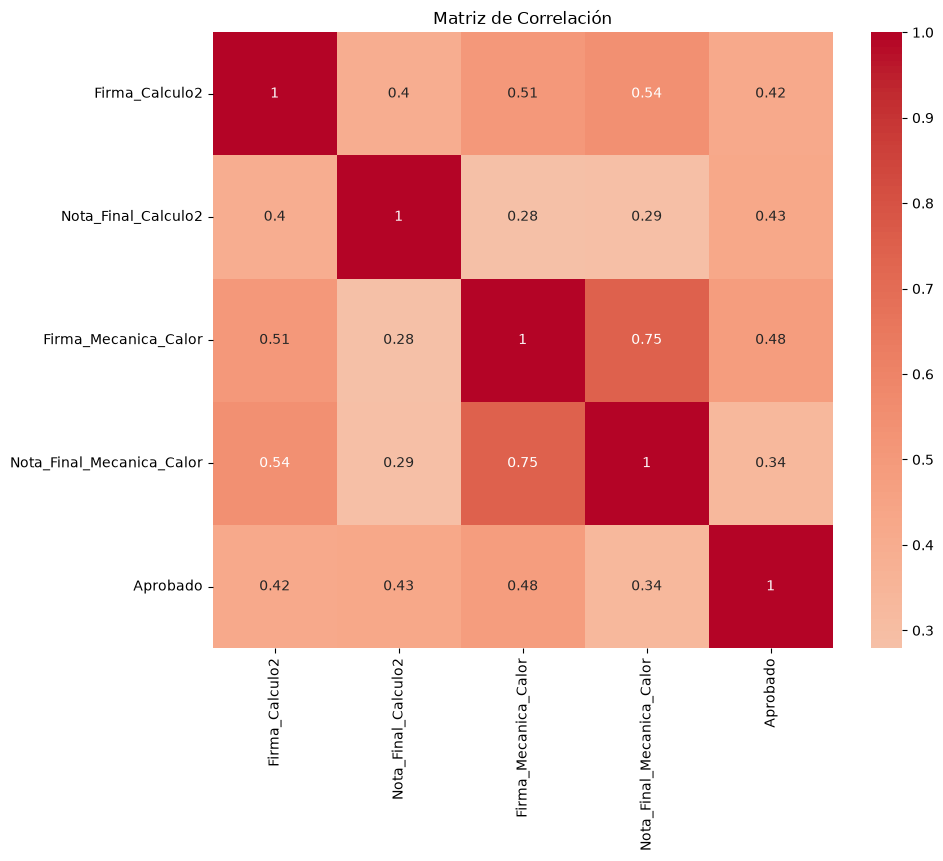

In [40]:
# =============================================================================
# 4. ANÁLISIS EXPLORATORIO
# =============================================================================
print("\n" + "="*80)
print("📊 ANÁLISIS EXPLORATORIO")
print("="*80)

# Estadísticas por grupo
print("\n📋 Estadísticas por estado (Aprobado vs Reprobado):")
for var in variables_existentes:
    print(f"\n{var}:")
    print(df_limpio.groupby('Aprobado')[var].agg(['count', 'mean', 'std', 'min', 'max']))

# Correlaciones
print("\n📈 Correlación con Aprobado:")
correlaciones = df_limpio[variables_existentes + ['Aprobado']].corr()['Aprobado'].sort_values(ascending=False)
print(correlaciones)

# Visualizaciones
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(variables_existentes[:6]):
    df_limpio.boxplot(column=var, by='Aprobado', ax=axes[i])
    axes[i].set_title(f'{var} por Estado')
    axes[i].set_xlabel('Aprobado (0=No, 1=Sí)')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

# Matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df_limpio[variables_existentes + ['Aprobado']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

In [43]:
# =============================================================================
# 9. MODELO 2: PREVIAS + PRIMER PARCIAL DE ESTATICA
# =============================================================================
print("\n" + "="*80)
print("🤖 MODELO 2: Previas + Primer Parcial")
print("="*80)

# Mismas variables previas + el primer parcial de Estática
variables_p1 = variables_existentes + ['Primer.Par']
variables_p1_existentes = [v for v in variables_p1 if v in df_estatica_aprobados.columns]

df_modelo_p1 = df_estatica_aprobados[variables_p1_existentes].copy()
df_modelo_p1['Aprobado'] = df_estatica_aprobados['Aprobado'].map({'S': 1, 'N': 0})

for col in variables_p1_existentes:
    df_modelo_p1[col] = pd.to_numeric(df_modelo_p1[col], errors='coerce')

df_limpio_p1 = df_modelo_p1.dropna()

print(f"   Variables usadas: {variables_p1_existentes}")
print(f"   Registros: {len(df_modelo_p1):,} -> {len(df_limpio_p1):,} tras limpiar")

X_p1 = df_limpio_p1[variables_p1_existentes]
y_p1 = df_limpio_p1['Aprobado']

X_train_p1, X_test_p1, y_train_p1, y_test_p1 = train_test_split(
    X_p1, y_p1, test_size=0.3, random_state=42, stratify=y_p1
)

scaler_p1 = StandardScaler()
X_train_p1_scaled = scaler_p1.fit_transform(X_train_p1)
X_test_p1_scaled = scaler_p1.transform(X_test_p1)

model_p1 = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_p1.fit(X_train_p1_scaled, y_train_p1)

y_pred_p1 = model_p1.predict(X_test_p1_scaled)
y_pred_proba_p1 = model_p1.predict_proba(X_test_p1_scaled)[:, 1]

print("\n📊 MÉTRICAS DEL MODELO 2:")
print(f"• Exactitud (Accuracy): {accuracy_score(y_test_p1, y_pred_p1):.3f}")
print(f"• AUC-ROC: {roc_auc_score(y_test_p1, y_pred_proba_p1):.3f}")

print("\n• Reporte de Clasificación:")
print(classification_report(y_test_p1, y_pred_p1, target_names=['Reprobado', 'Aprobado']))

cm_p1 = confusion_matrix(y_test_p1, y_pred_p1)
print("\n• Matriz de Confusión:")
print(pd.DataFrame(cm_p1, index=['Reprobado', 'Aprobado'], columns=['Pred_Reprobado', 'Pred_Aprobado']))

feature_importance_p1 = pd.DataFrame({
    'Variable': variables_p1_existentes,
    'Coeficiente': model_p1.coef_[0],
    'Odds_Ratio': np.exp(model_p1.coef_[0])
}).sort_values('Coeficiente', ascending=False)

print("\n🎯 Importancia de Variables (Modelo 2):")
print(feature_importance_p1)

# =============================================================================
# 10. COMPARACIÓN MODELO 1 (solo previas) vs MODELO 2 (previas + P1)
# =============================================================================
print("\n" + "="*80)
print("📊 COMPARACIÓN DE MODELOS")
print("="*80)
comparacion = pd.DataFrame({
    'Modelo': ['Solo previas', 'Previas + Primer Parcial'],
    'Accuracy': [accuracy_score(y_test, y_pred), accuracy_score(y_test_p1, y_pred_p1)],
    'AUC-ROC': [roc_auc_score(y_test, y_pred_proba), roc_auc_score(y_test_p1, y_pred_proba_p1)]
})
print(comparacion)


🤖 MODELO 2: Previas + Primer Parcial
   Variables usadas: ['Firma_Calculo2', 'Nota_Final_Calculo2', 'Firma_Mecanica_Calor', 'Nota_Final_Mecanica_Calor', 'Primer.Par']
   Registros: 96 -> 96 tras limpiar

📊 MÉTRICAS DEL MODELO 2:
• Exactitud (Accuracy): 0.759
• AUC-ROC: 0.799

• Reporte de Clasificación:
              precision    recall  f1-score   support

   Reprobado       0.69      0.75      0.72        12
    Aprobado       0.81      0.76      0.79        17

    accuracy                           0.76        29
   macro avg       0.75      0.76      0.75        29
weighted avg       0.76      0.76      0.76        29


• Matriz de Confusión:
           Pred_Reprobado  Pred_Aprobado
Reprobado               9              3
Aprobado                4             13

🎯 Importancia de Variables (Modelo 2):
                    Variable  Coeficiente  Odds_Ratio
1        Nota_Final_Calculo2         1.04        2.83
2       Firma_Mecanica_Calor         0.72        2.06
4                 


📈 Generando visualizaciones del Modelo 2...


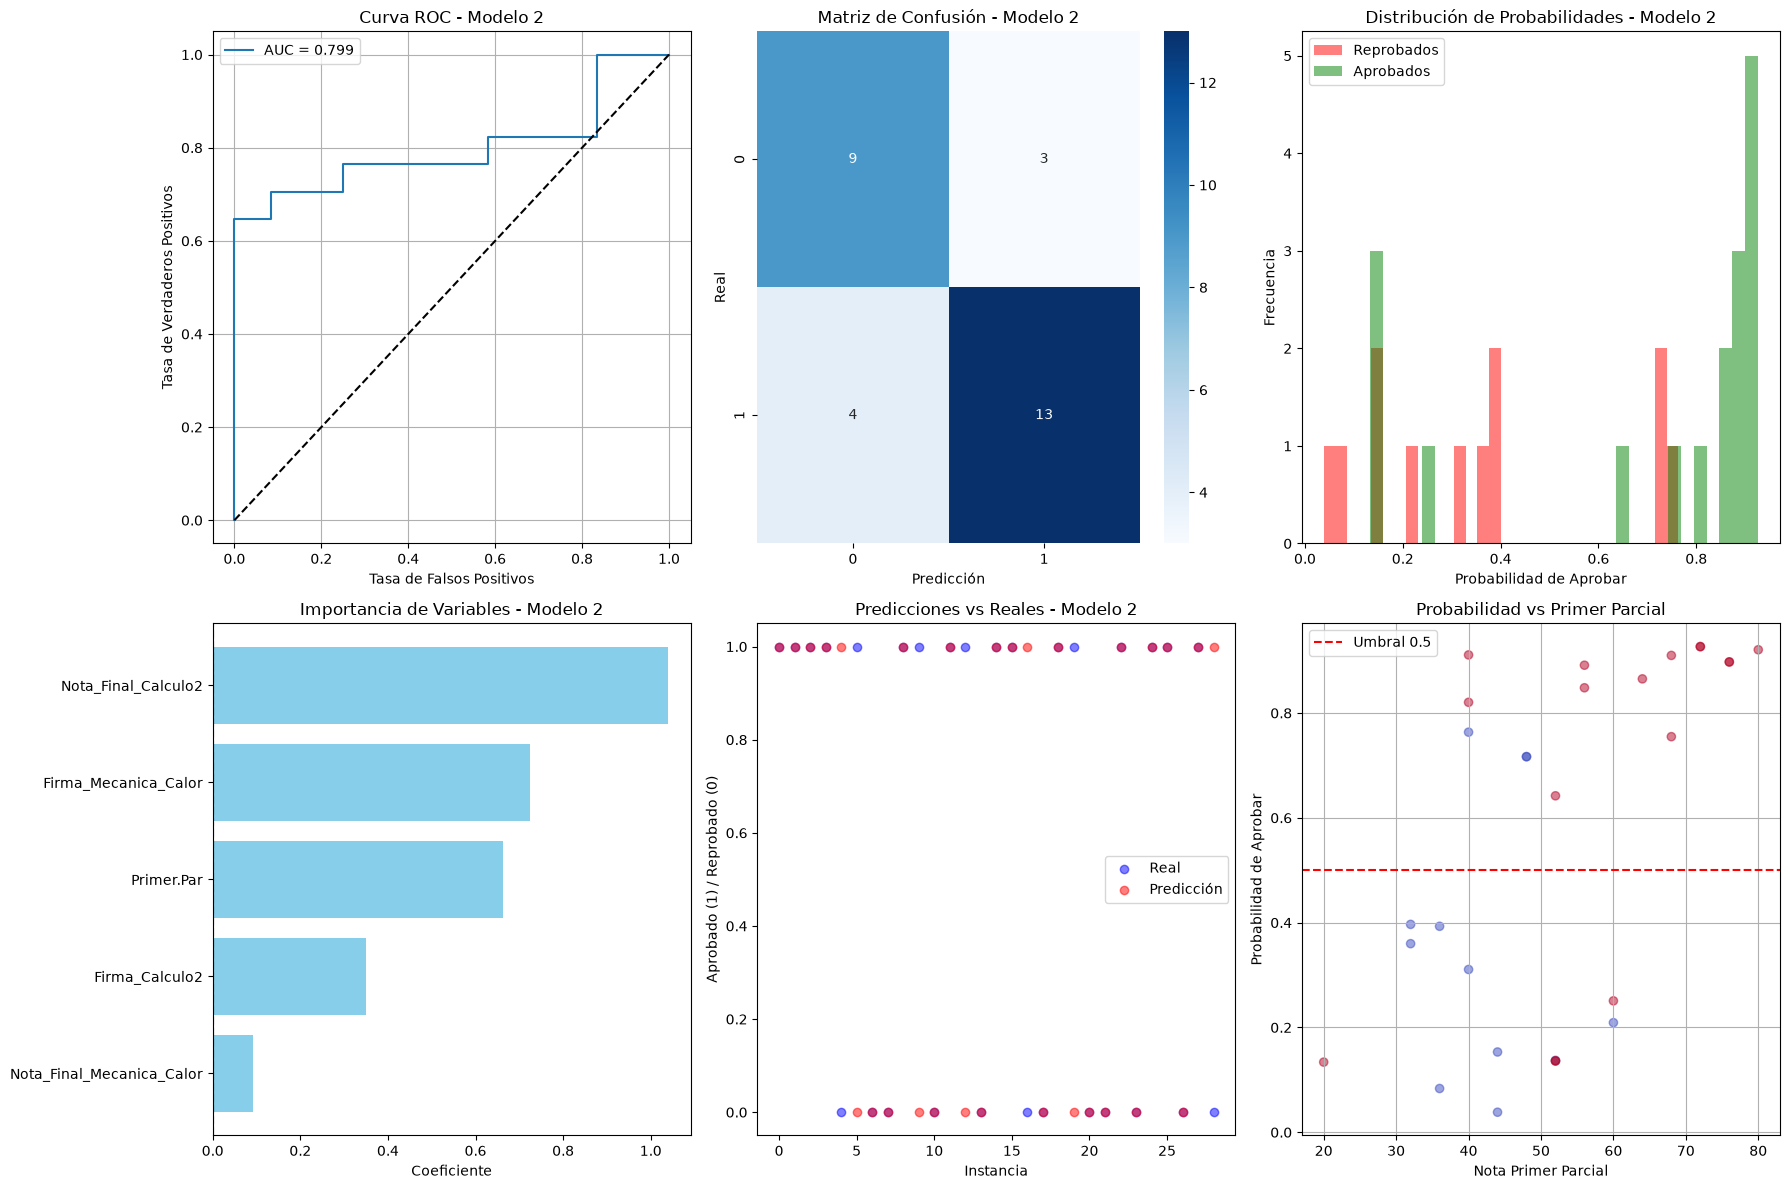

In [44]:
# =============================================================================
# 11. VISUALIZACIONES - MODELO 2
# =============================================================================
print("\n📈 Generando visualizaciones del Modelo 2...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Curva ROC
fpr_p1, tpr_p1, _ = roc_curve(y_test_p1, y_pred_proba_p1)
auc_p1 = roc_auc_score(y_test_p1, y_pred_proba_p1)
axes[0, 0].plot(fpr_p1, tpr_p1, label=f'AUC = {auc_p1:.3f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--')
axes[0, 0].set_xlabel('Tasa de Falsos Positivos')
axes[0, 0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0, 0].set_title('Curva ROC - Modelo 2')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Matriz de Confusión
sns.heatmap(cm_p1, annot=True, fmt='d', ax=axes[0, 1], cmap='Blues')
axes[0, 1].set_title('Matriz de Confusión - Modelo 2')
axes[0, 1].set_xlabel('Predicción')
axes[0, 1].set_ylabel('Real')

# 3. Distribución de Probabilidades
axes[0, 2].hist(y_pred_proba_p1[y_test_p1 == 0], bins=30, alpha=0.5, label='Reprobados', color='red')
axes[0, 2].hist(y_pred_proba_p1[y_test_p1 == 1], bins=30, alpha=0.5, label='Aprobados', color='green')
axes[0, 2].set_xlabel('Probabilidad de Aprobar')
axes[0, 2].set_ylabel('Frecuencia')
axes[0, 2].set_title('Distribución de Probabilidades - Modelo 2')
axes[0, 2].legend()

# 4. Importancia de Variables
importance_p1 = pd.DataFrame({
    'Variable': variables_p1_existentes,
    'Coeficiente': model_p1.coef_[0]
}).sort_values('Coeficiente', ascending=True)

axes[1, 0].barh(importance_p1['Variable'], importance_p1['Coeficiente'], color='skyblue')
axes[1, 0].set_xlabel('Coeficiente')
axes[1, 0].set_title('Importancia de Variables - Modelo 2')
axes[1, 0].axvline(x=0, color='black', linestyle='--')

# 5. Predicciones vs Reales
axes[1, 1].scatter(range(len(y_test_p1)), y_test_p1, alpha=0.5, label='Real', color='blue')
axes[1, 1].scatter(range(len(y_test_p1)), y_pred_p1, alpha=0.5, label='Predicción', color='red')
axes[1, 1].set_xlabel('Instancia')
axes[1, 1].set_ylabel('Aprobado (1) / Reprobado (0)')
axes[1, 1].set_title('Predicciones vs Reales - Modelo 2')
axes[1, 1].legend()

# 6. Primer Parcial vs Probabilidad (reemplaza el panel de 'Firma', ahora no aplica)
if 'Primer.Par' in variables_p1_existentes:
    axes[1, 2].scatter(X_test_p1['Primer.Par'], y_pred_proba_p1, alpha=0.5, c=y_test_p1, cmap='coolwarm')
    axes[1, 2].set_xlabel('Nota Primer Parcial')
    axes[1, 2].set_ylabel('Probabilidad de Aprobar')
    axes[1, 2].set_title('Probabilidad vs Primer Parcial')
    axes[1, 2].axhline(y=0.5, color='red', linestyle='--', label='Umbral 0.5')
    axes[1, 2].legend()
    axes[1, 2].grid(True)

plt.tight_layout()
plt.show()